# Generating images with DDPMs: A PyTorch Implementation

Denoise Diffusion Probabilistic Models (DDPMs) are generative models based on the idea of reversing a noising process. The idea is fairly simple: Given a dataset, make it more and more noisy with a deterministic process. Then, learn a model that can undo this process.

In [1]:
!pip3 install --upgrade pip
!pip3 install einops
!pip3 install imageio

Traceback (most recent call last):
  File "/usr/bin/pip3", line 8, in <module>
    sys.exit(main())
  File "/home/tmedi/.local/lib/python3.10/site-packages/pip/_internal/cli/main.py", line 84, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
  File "/home/tmedi/.local/lib/python3.10/site-packages/pip/_internal/commands/__init__.py", line 121, in create_command
    module = importlib.import_module(module_path)
  File "/usr/lib/python3.10/importlib/__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
  File "<frozen importlib._bootstrap>", line 1050, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1027, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1006, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 688, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 883, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _

In [2]:
import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Subset
import copy

In [ ]:
def show_images(images, title=""):
    """Shows the provided images as sub-pictures in a square"""
    images = [np.clip(im.permute(1,2,0).numpy(),0,1) for im in images]

    # Defining number of rows and columns
    fig = plt.figure(figsize=(8, 8))
    rows = int(len(images) ** (1 / 2))
    cols = round(len(images) / rows)

    # Populating figure with sub-plots
    idx = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, idx + 1)

            if idx < len(images):
                plt.imshow(images[idx])
                plt.axis('off')
                idx += 1
    fig.suptitle(title, fontsize=30)
    
    # Showing the figure
    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def sinusoidal_embedding(n, d):
    # Returns the standard positional embedding
    embedding = torch.tensor([[i / 10_000 ** (2 * j / d) for j in range(d)] for i in range(n)])
    sin_mask = torch.arange(0, n, 2)
    embedding[sin_mask] = torch.sin(embedding[sin_mask])
    embedding[1 - sin_mask] = torch.cos(embedding[sin_mask])
    return embedding

In [ ]:
class double_conv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(double_conv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv(x)
        return x

class down_layer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(down_layer, self).__init__()
        self.pool = nn.MaxPool2d(2, stride=2, padding=0)
        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x):
        x = self.conv(self.pool(x))
        return x

class up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(up, self).__init__()
        self.up_scale = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)

    def forward(self, x1, x2): # x1 (bs,out_ch,w1,h1) x2 (bs,in_ch,w2,h2)
        x2 = self.up_scale(x2) # (bs,out_ch,2*w2,2*h2)
        diffY = x1.size()[2] - x2.size()[2]
        diffX = x1.size()[3] - x2.size()[3]

        x2 = F.pad(x2, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2]) # (bs,out_ch,w1,h1)
        x = torch.cat([x2, x1], dim=1) # (bs,2*out_ch,w1,h1)
        return x

class up_layer(nn.Module):
    def __init__(self, in_ch, out_ch): # !! 2*out_ch = in_ch !!
        super(up_layer, self).__init__()
        self.up = up(in_ch, out_ch)
        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x1, x2): # x1 (bs,out_ch,w1,h1) x2 (bs,in_ch,w2,h2)
        a = self.up(x1, x2) # (bs,2*out_ch,w1,h1)
        x = self.conv(a) # (bs,out_ch,w1,h1) because 2*out_ch = in_ch
        return x

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, n_steps=1000, time_emb_dim=100):
        super(UNet, self).__init__()
        self.conv1 = double_conv(in_channels, 64)
        self.down1 = down_layer(64, 128)
        self.down2 = down_layer(128, 256)
        self.down3 = down_layer(256, 512)
        self.down4 = down_layer(512, 1024)
        self.up1 = up_layer(1024, 512)
        self.up2 = up_layer(512, 256)
        self.up3 = up_layer(256, 128)
        self.up4 = up_layer(128, 64)
        self.last_conv = nn.Conv2d(64, in_channels, 1)
        
        # Time embedding
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)
        self.te1 = self._make_te(time_emb_dim, in_channels)
        self.te2 = self._make_te(time_emb_dim, 64)
        self.te3 = self._make_te(time_emb_dim, 128)
        self.te4 = self._make_te(time_emb_dim, 256)
        self.te5 = self._make_te(time_emb_dim, 512)
        self.te1_up = self._make_te(time_emb_dim, 1024)
        self.te2_up = self._make_te(time_emb_dim, 512)
        self.te3_up = self._make_te(time_emb_dim, 256)
        self.te4_up = self._make_te(time_emb_dim, 128)

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(nn.Linear(dim_in, dim_out), nn.SiLU(), nn.Linear(dim_out, dim_out))
    
    def forward(self, x , t): # x (bs,in_channels,w,d)
        bs = x.shape[0]
        t = self.time_embed(t)
        x1 = self.conv1(x+self.te1(t).reshape(bs, -1, 1, 1)) # (bs,64,w,d)
        x2 = self.down1(x1+self.te2(t).reshape(bs, -1, 1, 1)) # (bs,128,w/2,d/2)
        x3 = self.down2(x2+self.te3(t).reshape(bs, -1, 1, 1)) # (bs,256,w/4,d/4)
        x4 = self.down3(x3+self.te4(t).reshape(bs, -1, 1, 1)) # (bs,512,w/8,h/8)
        x5 = self.down4(x4+self.te5(t).reshape(bs, -1, 1, 1)) # (bs,1024,w/16,h/16)
        x1_up = self.up1(x4, x5+self.te1_up(t).reshape(bs, -1, 1, 1)) # (bs,512,w/8,h/8)
        x2_up = self.up2(x3, x1_up+self.te2_up(t).reshape(bs, -1, 1, 1)) # (bs,256,w/4,h/4)
        x3_up = self.up3(x2, x2_up+self.te3_up(t).reshape(bs, -1, 1, 1)) # (bs,128,w/2,h/2)
        x4_up = self.up4(x1, x3_up+self.te4_up(t).reshape(bs, -1, 1, 1)) # (bs,64,w,h)
        output = self.last_conv(x4_up) # (bs,in_channels,w,h)
        return output

In [8]:


bs = 3
x = torch.randn(bs,1,32,32)
n_steps=1000
timesteps = torch.randint(0, n_steps, (bs,)).long()
unet = UNet()



In [9]:
y = unet(x,timesteps)
y.shape

torch.Size([3, 1, 32, 32])

In [ ]:


class DDPM(nn.Module):
    def __init__(self, network, num_timesteps, beta_start=0.0001, beta_end=0.02, device=device) -> None:
        super(DDPM, self).__init__()
        self.num_timesteps = num_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, dtype=torch.float32).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.network = network
        self.device = device
        self.sqrt_alphas_cumprod = self.alphas_cumprod ** 0.5 # used in add_noise
        self.sqrt_one_minus_alphas_cumprod = (1 - self.alphas_cumprod) ** 0.5 # used in add_noise and step

    def add_noise(self, x_start, x_noise, timesteps):
        # The forward process
        # x_start and x_noise (bs, n_c, w, d)
        # timesteps (bs)
        s1 = self.sqrt_alphas_cumprod[timesteps] # bs
        s2 = self.sqrt_one_minus_alphas_cumprod[timesteps] # bs
        s1 = s1.reshape(-1,1,1,1) # (bs, 1, 1, 1) for broadcasting
        s2 = s2.reshape(-1,1,1,1) # (bs, 1, 1, 1)
        return s1 * x_start + s2 * x_noise

    def reverse(self, x, t):
        # The network return the estimation of the noise we added
        return self.network(x, t)
    
    def step(self, model_output, timestep, sample):
        # one step of sampling
        # timestep (1)
        t = timestep
        coef_epsilon = (1-self.alphas)/self.sqrt_one_minus_alphas_cumprod
        coef_eps_t = coef_epsilon[t].reshape(-1,1,1,1)
        coef_first = 1/self.alphas ** 0.5
        coef_first_t = coef_first[t].reshape(-1,1,1,1)
        pred_prev_sample = coef_first_t*(sample-coef_eps_t*model_output)

        variance = 0
        if t > 0:
            noise = torch.randn_like(model_output).to(self.device)
            variance = ((self.betas[t] ** 0.5) * noise)
            
        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample



In [11]:
def training_loop(model, dataloader, optimizer, num_epochs, num_timesteps, device=device):
    """Training loop for DDPM"""

    global_step = 0
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        progress_bar = tqdm(total=len(dataloader))
        progress_bar.set_description(f"Epoch {epoch}")
        for step, batch in enumerate(dataloader):
            batch = batch[0].to(device)
            noise = torch.randn(batch.shape).to(device)
            timesteps = torch.randint(0, num_timesteps, (batch.shape[0],)).long().to(device)

            noisy = model.add_noise(batch, noise, timesteps)
            noise_pred = model.reverse(noisy, timesteps)
            loss = F.mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "step": global_step}
            losses.append(loss.detach().item())
            progress_bar.set_postfix(**logs)
            global_step += 1
        
        progress_bar.close()


In [12]:
root_dir = './data/'
transforms01 = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        #torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
dataset = torchvision.datasets.CIFAR10(root=root_dir, train=True, transform=transforms01, download=True)
dataloader = torch.utils.data.DataLoader(dataset=dataset, batch_size=512, shuffle=True,num_workers=10)

Files already downloaded and verified


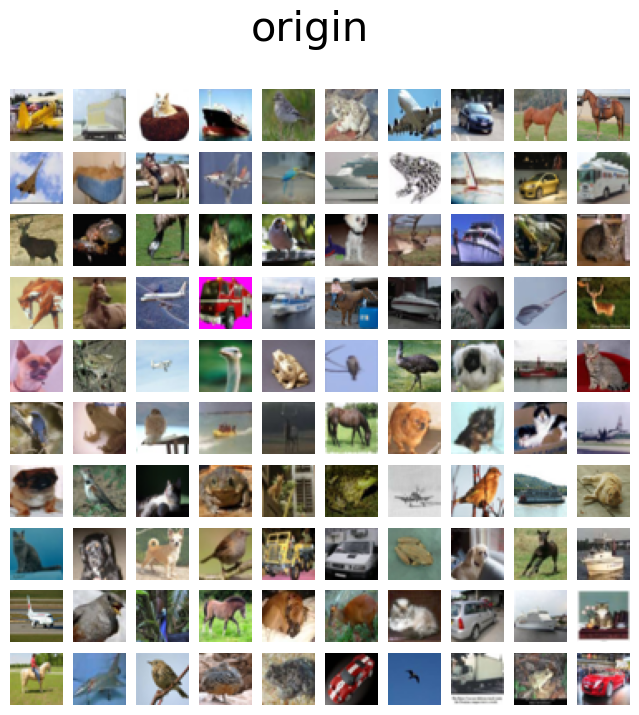

In [13]:
for b in dataloader:
    batch = b[0]
    break

bn = [b for b in batch[:100]] 
show_images(bn, "origin")

In [14]:
def save_checkpoint(model, optimizer, epoch, filename="ddpm_checkpoint.pth"):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
    }
    torch.save(checkpoint, filename)

In [15]:
learning_rate = 1e-3
num_epochs = 250
num_timesteps = 1000
network = UNet(in_channels=3)
network.to(device)
model = DDPM(network, num_timesteps, beta_start=0.0001, beta_end=0.02, device=device)
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
training_loop(model, dataloader, optimizer, num_epochs, num_timesteps, device=device) 
save_checkpoint(model, optimizer, num_epochs)

Epoch 249: 100%|██████████| 98/98 [00:10<00:00,  9.52it/s, loss=0.0162, step=24499]


In [24]:
def load_checkpoint(model, optimizer, filename="ddpm_checkpoint.pth"):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    return model, optimizer, start_epoch

In [25]:
model, optimizer, start_epoch = load_checkpoint(model, optimizer)
model.to(device)

/tmp/ipykernel_399200/4237084217.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename, map_location=device)


DDPM(
  (network): UNet(
    (conv1): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (down1): down_layer(
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (conv): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e

In [26]:
def generate_image(ddpm, sample_size, channel, size):
    """Generate the image from the Gaussian noise"""

    frames = []
    frames_mid = []
    ddpm.eval()
    with torch.no_grad():
        timesteps = list(range(ddpm.num_timesteps))[::-1]
        sample = torch.randn(sample_size, channel, size, size).to(device)
        
        for i, t in enumerate(tqdm(timesteps)):
            time_tensor = (torch.ones(sample_size) * t).long().to(device)
            residual = ddpm.reverse(sample, time_tensor).to(device)
            sample = ddpm.step(residual, time_tensor[0], sample)

            if t==500:
                #sample_squeezed = torch.squeeze(sample)
                for i in range(sample_size):
                    frames_mid.append(sample[i].detach().cpu())

        #sample = torch.squeeze(sample)
        for i in range(sample_size):
            frames.append(sample[i].detach().cpu())
    return frames, frames_mid

In [27]:
generated, generated_mid = generate_image(model, 100, 3, 32)

100%|██████████| 1000/1000 [00:05<00:00, 191.95it/s]


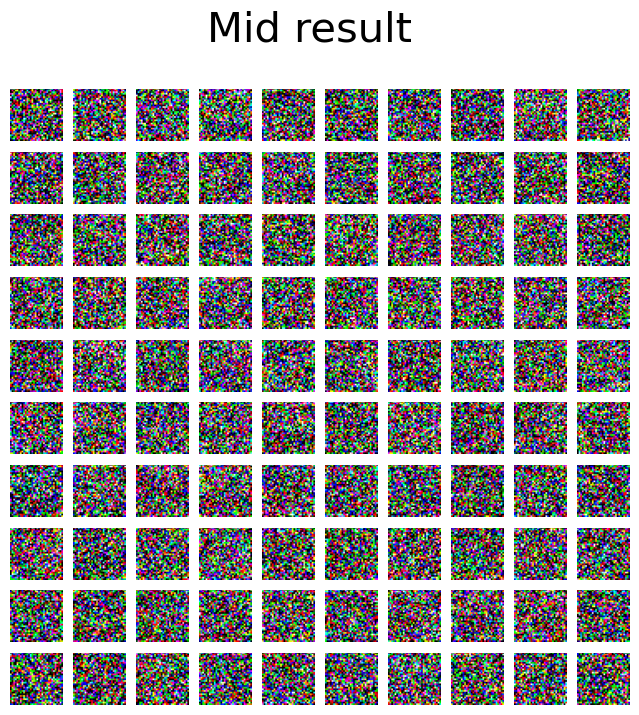

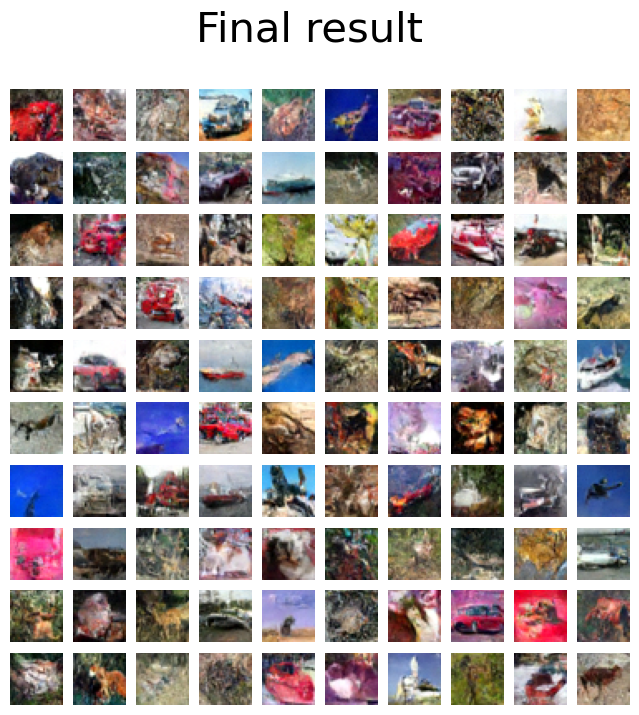

In [28]:
show_images(generated_mid, "Mid result")
show_images(generated, "Final result")

TO DOs

1. How would you evaluate the quality of generated Images?

In [30]:
import torch
import torchvision.transforms as transforms
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.datasets import CIFAR10
from torchvision.utils import save_image
from torchvision.transforms.functional import resize
from torch.utils.data import DataLoader

def evaluate_fid(generated_samples, device='cuda'):
    """
    Computes the FID score between generated samples and real CIFAR-10 images.

    Args:
        generated_samples: list of torch.Tensor images (C, H, W), in [0, 1] range
        device: 'cuda' or 'cpu'
    """
    # Prepare FID metric
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)

    # Transform: resize to 256x256 and convert to uint8
    def preprocess(img):
        img = resize(img, (256, 256))
        img = (img * 255).clamp(0, 255).to(torch.uint8)
        return img

    # Preprocess and update real CIFAR-10 images
    real_dataset = CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
    real_loader = DataLoader(real_dataset, batch_size=32, shuffle=False)
    for real_batch, _ in real_loader:
        real_batch = torch.stack([preprocess(img) for img in real_batch])
        fid.update(real_batch.to(device), real=True)

    # Preprocess and update generated images
    gen_tensor = torch.stack([preprocess(img) for img in generated_samples])
    gen_loader = DataLoader(gen_tensor, batch_size=32, shuffle=False)
    for gen_batch in gen_loader:
        fid.update(gen_batch.to(device), real=False)

    score = fid.compute()
    print(f"FID Score: {score.item():.4f}")
    return score.item()


In [31]:
# Generate 500 samples from your model
frames, _ = generate_image(model, sample_size=500, channel=3, size=32)

# Evaluate FID
fid_score = evaluate_fid(generated_samples=frames, device=device)


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:27<00:00, 36.25it/s]


Files already downloaded and verified
FID Score: 117.2147
